### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

varianza :  1.0759458263886241


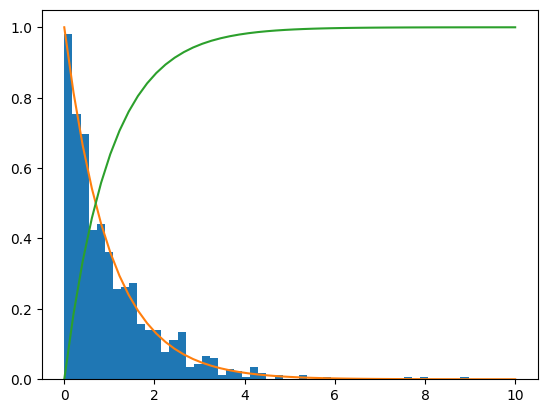

In [3]:
dist = sp.stats.gamma(a=1)
sample = dist.rvs(size = 1000)
plt.hist(sample, bins = 50, density = True)

x =np.linspace(0,10)
plt.plot(x, dist.pdf(x))

sp.stats.gamma.fit(sample)
cdf = dist.cdf(x)
plt.plot(x, cdf)
varianza = np.var(sample)
print('varianza : ', varianza)

### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

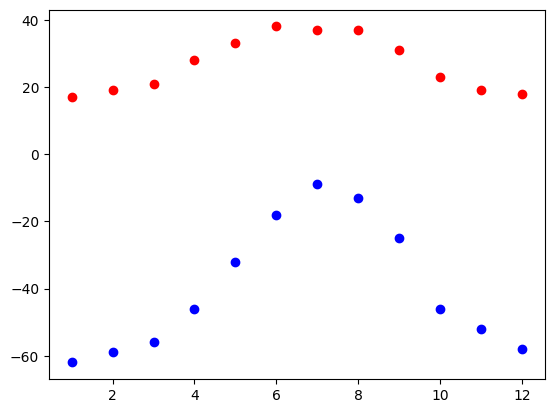

In [5]:
import numpy as np
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
import matplotlib.pyplot as plt

months = np.arange(1,13)
plt.plot(months, temp_max, "ro")
plt.plot(months, temp_min, "bo")


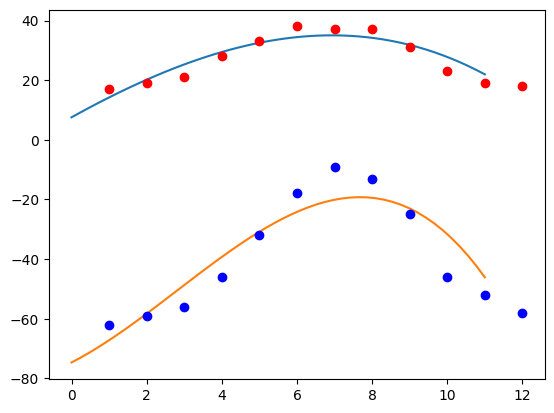

In [6]:
def polinomio_grado_3(x, a, b, c, d):
    return a*x**3 + b*x**2 + c*x + d

def sin(x, a, b, c, d):
    return c + a * np.sin((x+b)*2*np.pi/d)

params_max, _ = sp.optimize.curve_fit(polinomio_grado_3, months, temp_max) 
params_min, _ = sp.optimize.curve_fit(polinomio_grado_3, months, temp_min)

x = np.linspace(0,11)
plt.plot(x, polinomio_grado_3(x, *params_max))
plt.plot(months, temp_max, "ro")

plt.plot(x, polinomio_grado_3(x, *params_min))
plt.plot(months, temp_min, "bo")


### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

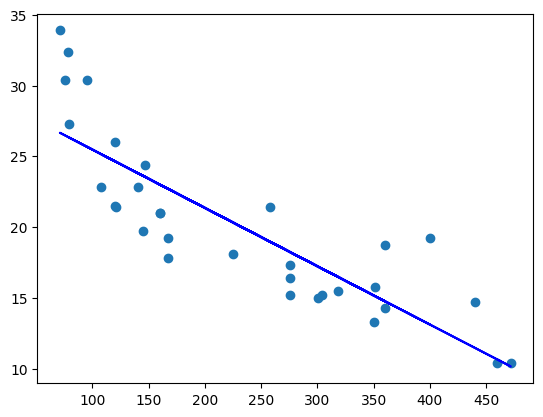

In [7]:
import pandas as pd

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
x = df['disp']
y = df['mpg']
slope, intercept, *_ = sp.stats.linregress(df['disp'], df['mpg'])
y_pred = slope*x + intercept
plt.scatter(x , y, label = 'True values')
plt.plot(x, y_pred, color = 'blue', label = 'Predicted values')



